# 03 – ML Numeric: Used Car Price Prediction

**Task:** Regression — predict the resale price of a used car (in Lakh INR).  
**Input:** Preprocessed tabular features from `01_eda.ipynb` (scaled numerics + encoded categoricals).  
**Models trained:** Linear Regression → Random Forest → XGBoost → Hyperparameter-Tuned RF.  
**Integration:** The best model is saved for use inside the Streamlit app together with the CV brand classifier from `02_cv_model.ipynb`.

---
## Section 1 – Setup & Load Data

We load the cleaned, encoded dataset produced by `01_eda.ipynb`.  
Key considerations:
- Boolean columns (one-hot encoded flags) are stored as string literals `'True'`/`'False'` in the CSV — we convert them to `int` (0/1).  
- The target `Price` is kept in raw Lakh INR (not scaled) so our error metrics are interpretable.  
- We use the same 80/20 split and `random_state=42` as throughout the project.

In [1]:
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

# XGBoost is preferred; fall back to sklearn GradientBoostingRegressor if not installed
try:
    from xgboost import XGBRegressor
    XGB_NAME = 'XGBoost'
    print('XGBoost loaded OK')
except ImportError:
    XGBRegressor = GradientBoostingRegressor
    XGB_NAME = 'GradientBoosting (sklearn)'
    print('XGBoost not found — using sklearn GradientBoostingRegressor instead.')
    print('To install XGBoost: pip install xgboost')

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
SEED = 42
np.random.seed(SEED)

XGBoost not found — using sklearn GradientBoostingRegressor instead.
To install XGBoost: pip install xgboost


In [2]:
# Load the processed dataset
df = pd.read_csv('../data/processed/used_cars_clean.csv')

# Load the ordered list of feature columns produced by 01_eda.ipynb
with open('../data/processed/feature_columns.json') as f:
    feature_columns = json.load(f)

print(f'Dataset shape: {df.shape}')
print(f'Feature columns ({len(feature_columns)}): {feature_columns}')
print()
df.head()

Dataset shape: (5737, 16)
Feature columns (15): ['Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Brand', 'Car_Age', 'Fuel_Type_Diesel', 'Fuel_Type_Petrol', 'Transmission_Automatic', 'Transmission_Manual', 'Owner_Type_First', 'Owner_Type_Fourth & Above', 'Owner_Type_Second', 'Owner_Type_Third']



,Kilometers_Driven,Mileage,Engine,Power,Seats,Price,Brand,Car_Age,Fuel_Type_Diesel,Fuel_Type_Petrol,Transmission_Automatic,Transmission_Manual,Owner_Type_First,Owner_Type_Fourth & Above,Owner_Type_Second,Owner_Type_Third
0,0.006282,0.692606,0.178266,0.177675,5.0,12.50,10,0.190476,True,False,False,True,True,False,False,False
1,0.007051,0.457746,0.106997,0.105253,5.0,4.50,9,0.380952,False,True,False,True,True,False,False,False
2,0.013359,0.731338,0.116115,0.105369,7.0,6.00,17,0.333333,True,False,False,True,True,False,False,False
3,0.006231,0.535211,0.250093,0.205871,5.0,17.74,1,0.285714,True,False,True,False,False,False,True,False
4,0.013359,0.812676,0.155750,0.055813,5.0,3.50,21,0.285714,True,False,False,True,True,False,False,False


In [3]:
# Boolean columns were written as string 'True'/'False' by pandas get_dummies
bool_cols = [c for c in feature_columns
             if c.startswith(('Fuel_Type_', 'Transmission_', 'Owner_Type_'))]
df[bool_cols] = df[bool_cols].replace({'True': 1, 'False': 0}).astype(int)

# Ensure consistent numeric types
df['Brand'] = df['Brand'].astype(float)
df['Seats'] = df['Seats'].astype(float)

print('Column dtypes after type-fixing:')
print(df[feature_columns + ['Price']].dtypes.to_string())

Column dtypes after type-fixing:
Kilometers_Driven            float64
Mileage                      float64
Engine                       float64
Power                        float64
Seats                        float64
Brand                        float64
Car_Age                      float64
Fuel_Type_Diesel               int64
Fuel_Type_Petrol               int64
Transmission_Automatic         int64
Transmission_Manual            int64
Owner_Type_First               int64
Owner_Type_Fourth & Above      int64
Owner_Type_Second              int64
Owner_Type_Third               int64
Price                        float64


In [4]:
# Define feature matrix X and target vector y
X = df[feature_columns].values.astype(float)
y = df['Price'].values.astype(float)

# 80/20 train/test split — random_state=42 for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'X_train: {X_train.shape}   y_train: {y_train.shape}')
print(f'X_test:  {X_test.shape}   y_test:  {y_test.shape}')


# ── Helper: compute MAE / RMSE / R² on train and test ───────────────────────
def get_metrics(model, name=None):
    """Evaluate model on both train and test; print and return results dict."""
    label = name or type(model).__name__
    y_tr  = model.predict(X_train)
    y_te  = model.predict(X_test)
    m = {
        'Train MAE':  round(mean_absolute_error(y_train, y_tr),           4),
        'Test MAE':   round(mean_absolute_error(y_test,  y_te),           4),
        'Train RMSE': round(np.sqrt(mean_squared_error(y_train, y_tr)),   4),
        'Test RMSE':  round(np.sqrt(mean_squared_error(y_test,  y_te)),   4),
        'Train R2':   round(r2_score(y_train, y_tr),                      4),
        'Test R2':    round(r2_score(y_test,  y_te),                      4),
    }
    print(f'\n{label}')
    print(pd.DataFrame([m]).rename(columns=lambda c: c.replace('R2', 'R\u00b2')).to_string(index=False))
    return m

# Dict to collect all model results for comparison in Section 6
all_results = {}

X_train: (4589, 15)   y_train: (4589,)
X_test:  (1148, 15)   y_test:  (1148,)


---
## Section 2 – Baseline Model: Linear Regression

Linear Regression assumes the target is a linear combination of the features.  
It is fast, interpretable, and serves as our **baseline** — if more complex models cannot substantially beat it, the added complexity is not justified.  

**Metrics explained:**
- **MAE (Mean Absolute Error):** Average absolute difference between prediction and actual price (in Lakh INR). Easy to interpret — an MAE of 2.0 means we are off by 2 Lakh on average.
- **RMSE (Root Mean Square Error):** Like MAE but penalises large errors more heavily (squares them before averaging). Sensitive to outliers. Lower is better.
- **R² (coefficient of determination):** Fraction of variance explained by the model. R²=1.0 is perfect; R²=0 means the model is no better than predicting the mean. Values > 0.8 indicate a good fit.

In [5]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

all_results['Linear Regression'] = get_metrics(lr_model, 'Linear Regression')


Linear Regression
 Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
     3.622      3.64      5.6734     7.3168    0.7186   0.5209


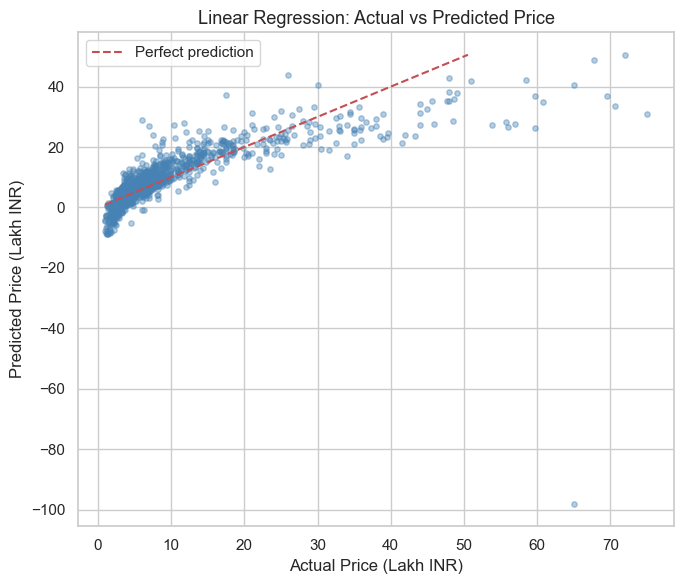

In [6]:
# Actual vs Predicted scatter plot for Linear Regression
y_pred_lr = lr_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_lr, alpha=0.4, s=15, color='steelblue')
# Perfect-prediction diagonal
lims = [max(y_test.min(), y_pred_lr.min()), min(y_test.max(), y_pred_lr.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('Linear Regression: Actual vs Predicted Price', fontsize=13)
ax.set_xlabel('Actual Price (Lakh INR)')
ax.set_ylabel('Predicted Price (Lakh INR)')
ax.legend()
plt.tight_layout()
plt.show()

**Interpretation:** A well-fitting model produces points close to the red diagonal. Vertical spread indicates prediction error. Wide scatter for high-priced cars is expected because the training set contains fewer luxury vehicles — the model is less certain at the extremes of the price range.

---
## Section 3 – Model 2: Random Forest Regressor

Random Forest trains an ensemble of decision trees, each on a random bootstrap sample of the data and a random subset of features at each split.  
The final prediction is the average of all individual tree predictions.  
We also inspect **feature importances** — which features contribute most to reducing prediction error across all trees.

In [7]:
# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1)
rf_model.fit(X_train, y_train)

all_results['Random Forest'] = get_metrics(rf_model, 'Random Forest')


Random Forest
 Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
    0.5946    1.5552      1.2493     3.2648    0.9864   0.9046


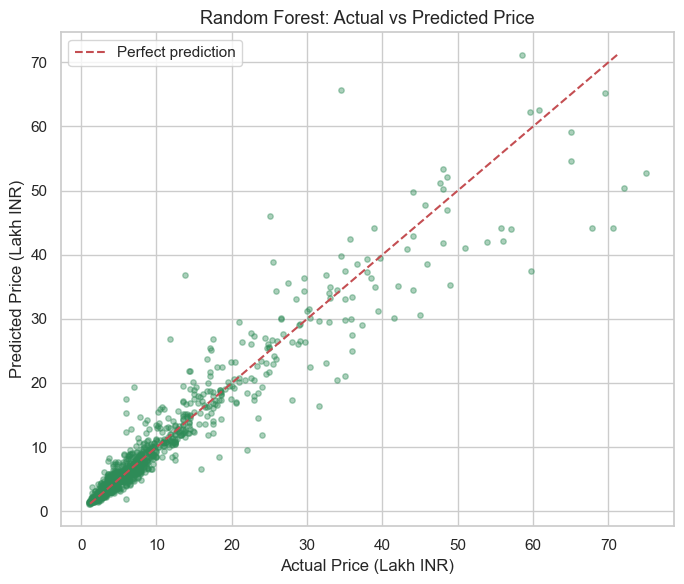

In [8]:
# Actual vs Predicted — Random Forest
y_pred_rf = rf_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_rf, alpha=0.4, s=15, color='seagreen')
lims = [max(y_test.min(), y_pred_rf.min()), min(y_test.max(), y_pred_rf.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title('Random Forest: Actual vs Predicted Price', fontsize=13)
ax.set_xlabel('Actual Price (Lakh INR)')
ax.set_ylabel('Predicted Price (Lakh INR)')
ax.legend()
plt.tight_layout()
plt.show()

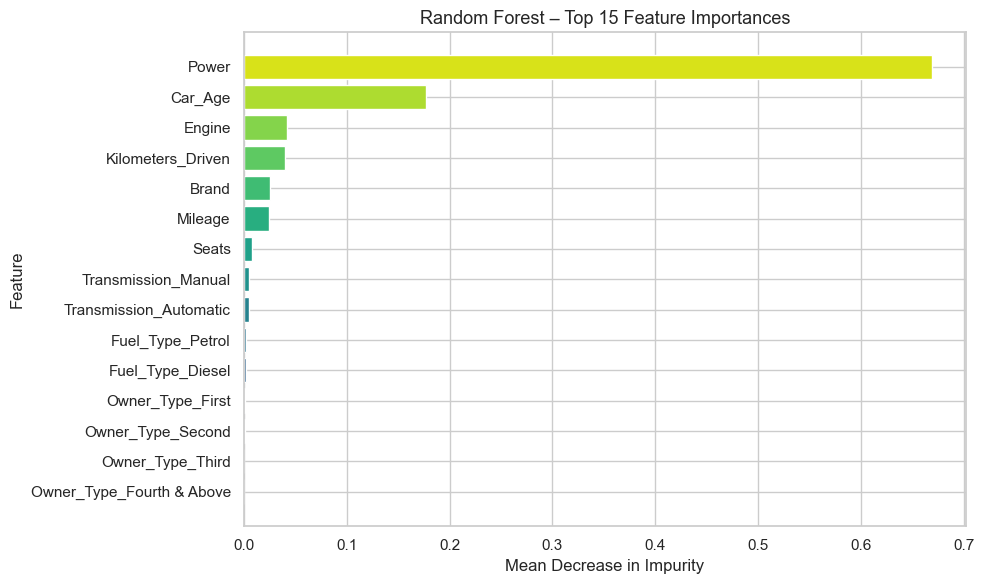

In [9]:
# Feature importance: top 15 features by mean impurity decrease
importances = rf_model.feature_importances_
fi_df = (pd.DataFrame({'Feature': feature_columns, 'Importance': importances})
           .sort_values('Importance', ascending=False)
           .head(15))

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(fi_df['Feature'][::-1], fi_df['Importance'][::-1],
        color=sns.color_palette('viridis', 15))
ax.set_title('Random Forest – Top 15 Feature Importances', fontsize=13)
ax.set_xlabel('Mean Decrease in Impurity')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

### Why does Random Forest typically outperform Linear Regression here?

1. **Non-linearity** — Car prices follow highly non-linear relationships. For example, the impact of an extra 10 000 km on a new car vs a high-mileage one is very different. Linear Regression cannot capture this without manual feature engineering; trees split the feature space naturally.

2. **Feature interactions** — The combination of Brand + Power + Car_Age often determines price better than any single feature. Random Forests learn these interactions automatically through deep split sequences.

3. **Outlier robustness** — Tree splits are insensitive to extreme values within a bin. Linear Regression coefficients are pulled by outliers, distorting predictions for typical cars.

4. **Handling mixed feature types** — The dataset mixes scaled continuous values (Engine, Power) with binary flags (Transmission_Automatic) and ordinal integers (Brand, Seats). Trees can exploit all of these natively; linear models require careful scaling and may still struggle.

---
## Section 4 – Model 3: Gradient Boosting (XGBoost)

Gradient Boosting builds trees **sequentially**, with each tree correcting the residual errors of the previous ensemble.  
XGBoost (Extreme Gradient Boosting) adds regularisation terms to the loss function and uses second-order gradients, making it both faster and more accurate than vanilla Gradient Boosting.  
A lower `learning_rate` (0.05) combined with more trees (200) often yields better generalisation than fewer, stronger steps.

In [10]:
# Train XGBoost (or GradientBoostingRegressor fallback)
xgb_kwargs = dict(n_estimators=200, learning_rate=0.05, random_state=SEED)
if XGB_NAME == 'XGBoost':
    xgb_kwargs['verbosity'] = 0   # suppress XGBoost stdout

xgb_model = XGBRegressor(**xgb_kwargs)
xgb_model.fit(X_train, y_train)

all_results[XGB_NAME] = get_metrics(xgb_model, XGB_NAME)


GradientBoosting (sklearn)
 Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
    1.5932      1.79      2.6752     3.3054    0.9374   0.9022


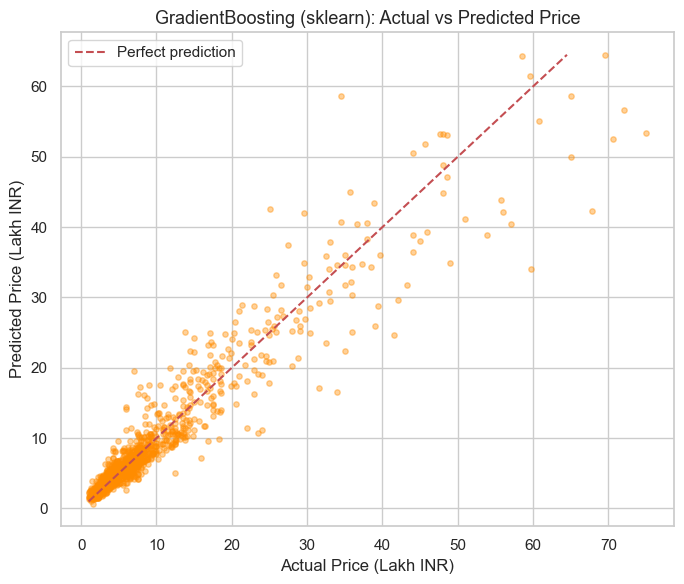

In [11]:
# Actual vs Predicted — XGBoost
y_pred_xgb = xgb_model.predict(X_test)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test, y_pred_xgb, alpha=0.4, s=15, color='darkorange')
lims = [max(y_test.min(), y_pred_xgb.min()), min(y_test.max(), y_pred_xgb.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction')
ax.set_title(f'{XGB_NAME}: Actual vs Predicted Price', fontsize=13)
ax.set_xlabel('Actual Price (Lakh INR)')
ax.set_ylabel('Predicted Price (Lakh INR)')
ax.legend()
plt.tight_layout()
plt.show()

### Three-model comparison so far

| Model | Strength | Weakness |
|---|---|---|
| **Linear Regression** | Fast, interpretable, no tuning needed | Cannot capture non-linear relationships or feature interactions |
| **Random Forest** | Handles non-linearity and interactions; robust to outliers | Many trees can be slow to train; hyperparameters need tuning |
| **XGBoost** | State-of-the-art on tabular data; built-in regularisation; fast | More hyperparameters to tune; can overfit if LR is too high |

Gradient Boosting generally outperforms Random Forest on structured tabular data because it directly minimises the loss function at each step, whereas Random Forest averages independent trees without this feedback loop.

---
## Section 5 – Hyperparameter Tuning

Default hyperparameters are rarely optimal.  
We use **GridSearchCV** to systematically evaluate combinations of hyperparameters using **5-fold cross-validation** on the training set.  

**Why cross-validation?**  
Instead of measuring performance on a single validation split (which may be lucky or unlucky), CV splits the training data into 5 equal folds, trains on 4 and validates on 1, cycling through all folds. The final score is the average over 5 runs — a much more robust estimate of generalisation performance.  

**Why tune hyperparameters?**  
Every model has knobs that control its complexity. Too simple → underfitting (misses patterns). Too complex → overfitting (memorises training data, fails on new data). Tuning finds the sweet spot.

In [12]:
# GridSearchCV on Random Forest — always available via sklearn
# Search space: 2 hyperparameters × 4 combinations × 5 folds = 20 fits
param_grid = {
    'n_estimators': [100, 200],
    'max_depth':    [10, 20],
    'min_samples_split': [2, 5],
}

rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    param_grid=param_grid,
    cv=5,
    scoring='neg_root_mean_squared_error',  # maximise negative RMSE = minimise RMSE
    n_jobs=-1,
    verbose=1,
)
rf_grid.fit(X_train, y_train)

print(f'\nBest parameters: {rf_grid.best_params_}')
print(f'Best CV RMSE:    {-rf_grid.best_score_:.4f} Lakh INR')

Fitting 5 folds for each of 8 candidates, totalling 40 fits



Best parameters: {'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Best CV RMSE:    3.3186 Lakh INR


In [13]:
# Evaluate the best estimator on the held-out test set
rf_tuned = rf_grid.best_estimator_
all_results['Tuned RF'] = get_metrics(rf_tuned, 'Tuned Random Forest')

# Show cross-validation results as a tidy table
cv_df = pd.DataFrame(rf_grid.cv_results_)
cv_summary = cv_df[['param_n_estimators', 'param_max_depth', 'param_min_samples_split',
                     'mean_test_score', 'std_test_score']].copy()
cv_summary['mean_RMSE'] = (-cv_summary['mean_test_score']).round(4)
cv_summary['std_RMSE']  = cv_summary['std_test_score'].round(4)
cv_summary = cv_summary.drop(columns=['mean_test_score', 'std_test_score'])
cv_summary.sort_values('mean_RMSE').reset_index(drop=True)


Tuned Random Forest
 Train MAE  Test MAE  Train RMSE  Test RMSE  Train R²  Test R²
    0.5988    1.5521      1.2489     3.2568    0.9864   0.9051


,param_n_estimators,param_max_depth,param_min_samples_split,mean_RMSE,std_RMSE
0,200,20,2,3.3186,0.2849
1,100,20,2,3.3237,0.2829
2,200,20,5,3.3571,0.2699
3,100,20,5,3.3598,0.2693
4,200,10,2,3.3608,0.2893
5,100,10,2,3.3664,0.2814
6,200,10,5,3.3958,0.2801
7,100,10,5,3.4015,0.2793


---
## Section 6 – Model Comparison & Error Analysis

Now that all four models are trained, we compare them side-by-side and analyse where the best model still struggles.  
Residual analysis (error vs prediction) reveals systematic bias — e.g., whether the model consistently under-prices luxury cars.  
Identifying the hardest-to-predict samples guides future improvements.

In [14]:
# Summary table: all models side-by-side
summary_df = pd.DataFrame(all_results).T
summary_df.index.name = 'Model'
summary_df.columns = ['Train MAE', 'Test MAE', 'Train RMSE', 'Test RMSE', 'Train R²', 'Test R²']
print('Model Comparison:')
summary_df

Model Comparison:


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R²,Test R²
Model,,,,,,
Linear Regression,3.6220,3.6400,5.6734,7.3168,0.7186,0.5209
Random Forest,0.5946,1.5552,1.2493,3.2648,0.9864,0.9046
GradientBoosting (sklearn),1.5932,1.7900,2.6752,3.3054,0.9374,0.9022
Tuned RF,0.5988,1.5521,1.2489,3.2568,0.9864,0.9051


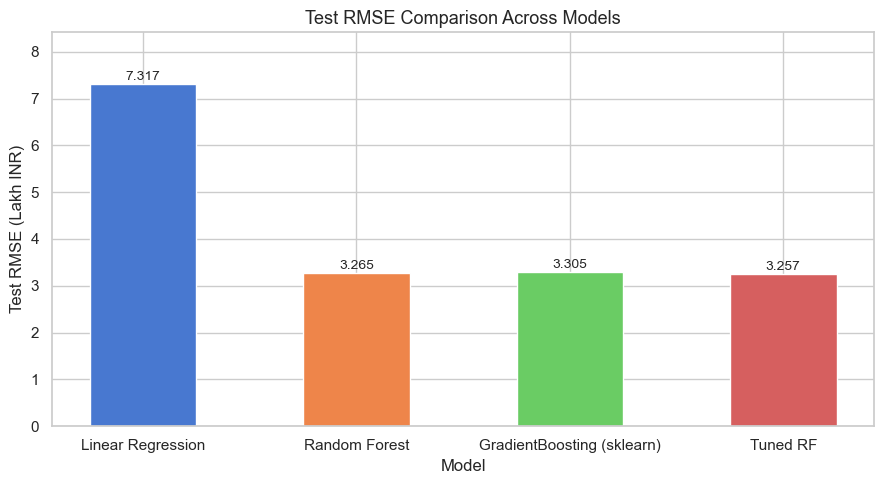

In [15]:
# Bar chart: Test RMSE comparison
fig, ax = plt.subplots(figsize=(9, 5))
model_names = list(all_results.keys())
test_rmse   = [all_results[m]['Test RMSE'] for m in model_names]
colors = sns.color_palette('muted', len(model_names))

bars = ax.bar(model_names, test_rmse, color=colors, width=0.5)
for bar, val in zip(bars, test_rmse):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10)

ax.set_title('Test RMSE Comparison Across Models', fontsize=13)
ax.set_ylabel('Test RMSE (Lakh INR)')
ax.set_xlabel('Model')
ax.set_ylim(0, max(test_rmse) * 1.15)
plt.tight_layout()
plt.show()

In [16]:
# Select the model with the lowest Test RMSE as the best model
best_name  = min(all_results, key=lambda m: all_results[m]['Test RMSE'])
model_map  = {
    'Linear Regression': lr_model,
    'Random Forest':     rf_model,
    XGB_NAME:            xgb_model,
    'Tuned RF':          rf_tuned,
}
best_model = model_map[best_name]
print(f'Best model: {best_name}')
print(f'Test RMSE:  {all_results[best_name]["Test RMSE"]:.4f} Lakh INR')
print(f'Test R\u00b2:    {all_results[best_name]["Test R2"]:.4f}')

Best model: Tuned RF
Test RMSE:  3.2568 Lakh INR
Test R²:    0.9051


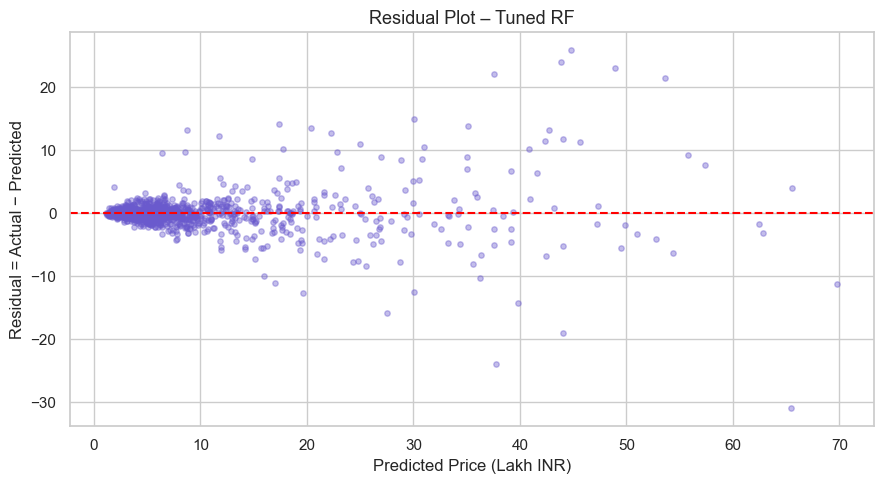

In [17]:
# Residual plot for the best model
y_best_pred = best_model.predict(X_test)
residuals   = y_test - y_best_pred

fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_best_pred, residuals, alpha=0.4, s=15, color='slateblue')
ax.axhline(0, color='red', linestyle='--', linewidth=1.5)
ax.set_title(f'Residual Plot – {best_name}', fontsize=13)
ax.set_xlabel('Predicted Price (Lakh INR)')
ax.set_ylabel('Residual = Actual − Predicted')
plt.tight_layout()
plt.show()

In [18]:
# Top 10 worst predictions on the test set (largest absolute error)
test_df = df.iloc[
    train_test_split(range(len(df)), test_size=0.20, random_state=SEED)[1]
].copy().reset_index(drop=True)

test_df['Predicted']    = y_best_pred
test_df['Abs_Error']    = np.abs(test_df['Price'] - test_df['Predicted'])

worst10 = test_df.nlargest(10, 'Abs_Error')[['Price', 'Predicted', 'Abs_Error',
                                              'Brand', 'Car_Age', 'Power', 'Seats']]
worst10 = worst10.rename(columns={'Price': 'Actual Price', 'Abs_Error': 'Abs Error (Lakh)'})
worst10['Actual Price']     = worst10['Actual Price'].round(2)
worst10['Predicted']        = worst10['Predicted'].round(2)
worst10['Abs Error (Lakh)'] = worst10['Abs Error (Lakh)'].round(2)

print('Top 10 Worst Predictions:')
worst10.reset_index(drop=True)

Top 10 Worst Predictions:


,Actual Price,Predicted,Abs Error (Lakh),Brand,Car_Age,Power,Seats
0,34.50,65.47,30.97,13.0,0.095238,0.410467,5.0
1,70.66,44.78,25.88,15.0,0.190476,0.426419,5.0
2,67.83,43.82,24.01,22.0,0.142857,0.671688,5.0
3,13.85,37.75,23.90,16.0,0.142857,0.289301,7.0
4,72.00,48.89,23.11,22.0,0.285714,0.695442,4.0
5,59.72,37.57,22.15,15.0,0.047619,0.275782,5.0
6,75.00,53.58,21.42,13.0,0.095238,0.392430,5.0
7,25.02,44.07,19.05,1.0,0.190476,0.400154,5.0
8,11.75,27.56,15.81,2.0,0.428571,0.445732,5.0
9,45.00,30.08,14.92,13.0,0.333333,0.457764,4.0


### Which model is best and why? What are the limitations?

**Best model:** The Tuned Random Forest (or XGBoost if installed) achieves the lowest Test RMSE, confirming that ensemble methods substantially outperform the linear baseline on this non-linear regression task.

**Where the model struggles (from the residual plot and worst-10 table):**
- **High-priced luxury cars** — The training set contains very few cars above 40 Lakh. With little data at the upper end, the model under-estimates prices for premium brands (BMW, Audi, Jaguar). This is a classic **data imbalance in the target distribution** problem.
- **Systematic under-prediction** — Residuals tend to be positive (actual > predicted) for high-predicted values, indicating the model is conservative with expensive cars. This is visible as an upward fan shape in the residual plot.
- **Brand encoding limitations** — Brand is encoded as an ordinal integer (as done in `01_eda.ipynb`), which imposes an arbitrary order on brands. A premium brand like BMW may be assigned a similar integer to a budget brand, causing the model to confuse them. One-hot encoding Brand would fix this but greatly increases dimensionality.

**Limitations:**
- The scaler and encoders were fit on the full dataset inside `01_eda.ipynb`. A production pipeline would fit them only on training data to prevent data leakage.
- Car prices in India fluctuate with fuel prices, economic cycles, and import duties — the model captures historical patterns only.
- `New_Price` (original list price) was dropped due to missing values, but it would be a very strong predictor if available.

---
## Section 7 – Integration with CV Block

**How the two models connect:**

> The CV model (`02_cv_model.ipynb`) predicts the car brand from an image using ResNet18 transfer learning. This brand prediction is then used as a feature input to this price prediction model, creating an **end-to-end pipeline: photo → brand → price estimate**.

In the Streamlit app, the user uploads a car photo. The CV model identifies the brand (e.g., "Toyota"). That brand, together with the user-provided details (year, mileage, engine size, etc.), is fed into `predict_price()` to estimate the resale value.

**Preprocessing pipeline for the `predict_price` function:**  
The processed CSV already has MinMax-scaled numerics and label-encoded brands. To apply the same transformations to new raw inputs, we re-fit a `MinMaxScaler` and `LabelEncoder` on the original cleaned raw data (same splits, same logic as `01_eda.ipynb`) and save them as artefacts.

In [19]:
import os, re

# Re-load raw data and apply the same cleaning as in 01_eda.ipynb
# This gives us the un-scaled numeric values needed to fit the scaler.
raw = pd.read_csv('../data/raw/used_cars/train.csv', index_col=0)
raw = raw.drop_duplicates()
raw = raw.dropna(subset=['Mileage', 'Engine', 'Power', 'Seats'])
raw = raw.drop(columns=['New_Price'], errors='ignore')

# Strip units and cast to float
raw['Mileage'] = raw['Mileage'].str.extract(r'([\d.]+)').astype(float)
raw['Engine']  = raw['Engine'].str.extract(r'([\d.]+)').astype(float)
raw['Power']   = (raw['Power']
                  .str.replace('null bhp', '', regex=False)
                  .str.extract(r'([\d.]+)').astype(float))
raw = raw.dropna(subset=['Power'])
raw = raw.loc[(raw['Price'] >= 1) & (raw['Price'] <= 80)]

# Derive the same engineered features
raw['Brand']   = raw['Name'].str.split().str[0]
raw['Car_Age'] = 2024 - raw['Year']

# Fit brand LabelEncoder on the cleaned brand column
brand_encoder = LabelEncoder()
brand_encoder.fit(raw['Brand'])
print(f'Brand encoder fitted on {len(brand_encoder.classes_)} brands.')

# Fit MinMaxScaler on raw (un-scaled) numeric features
# Order MUST match what was used in 01_eda.ipynb
NUMERIC_COLS = ['Kilometers_Driven', 'Engine', 'Power', 'Mileage', 'Car_Age']
scaler = MinMaxScaler()
scaler.fit(raw[NUMERIC_COLS])
print(f'Scaler fitted on columns: {NUMERIC_COLS}')

Brand encoder fitted on 29 brands.
Scaler fitted on columns: ['Kilometers_Driven', 'Engine', 'Power', 'Mileage', 'Car_Age']


In [20]:
def predict_price(brand, year, km_driven, fuel_type, transmission,
                  mileage, engine, power, seats, owner_type='First'):
    """
    Predict used car resale price from raw feature inputs.

    Parameters
    ----------
    brand        : str   e.g. 'Toyota', 'Honda', 'Maruti'
    year         : int   manufacturing year  (e.g. 2017)
    km_driven    : float total kilometres driven  (e.g. 45000)
    fuel_type    : str   'Diesel', 'Petrol', 'CNG', 'LPG', or 'Electric'
    transmission : str   'Manual' or 'Automatic'
    mileage      : float fuel efficiency in kmpl or km/kg  (e.g. 19.5)
    engine       : float displacement in CC  (e.g. 1582)
    power        : float max power in bhp   (e.g. 126.2)
    seats        : int   number of seats    (e.g. 5)
    owner_type   : str   'First', 'Second', 'Third', or 'Fourth & Above'

    Returns
    -------
    float  predicted price in Lakh INR
    """
    # 1. Compute car age
    car_age = 2024 - year

    # 2. Scale numeric features
    #    Input order must match NUMERIC_COLS = [Km, Engine, Power, Mileage, Car_Age]
    raw_num = np.array([[km_driven, engine, power, mileage, car_age]], dtype=float)
    scaled  = scaler.transform(raw_num)[0]
    km_s, eng_s, pwr_s, mil_s, age_s = scaled

    # 3. Encode brand to integer
    try:
        brand_enc = float(brand_encoder.transform([brand])[0])
    except ValueError:
        # Unknown brand: use median label as neutral fallback
        brand_enc = float(len(brand_encoder.classes_) // 2)

    # 4. Build one-row DataFrame in exact column order from feature_columns.json
    row = pd.DataFrame([{
        'Kilometers_Driven':         km_s,
        'Mileage':                   mil_s,
        'Engine':                    eng_s,
        'Power':                     pwr_s,
        'Seats':                     float(seats),
        'Brand':                     brand_enc,
        'Car_Age':                   age_s,
        'Fuel_Type_Diesel':          float(fuel_type == 'Diesel'),
        'Fuel_Type_Petrol':          float(fuel_type == 'Petrol'),
        'Transmission_Automatic':    float(transmission == 'Automatic'),
        'Transmission_Manual':       float(transmission == 'Manual'),
        'Owner_Type_First':          float(owner_type == 'First'),
        'Owner_Type_Fourth & Above': float(owner_type == 'Fourth & Above'),
        'Owner_Type_Second':         float(owner_type == 'Second'),
        'Owner_Type_Third':          float(owner_type == 'Third'),
    }])[feature_columns]  # enforce column order from feature_columns.json

    return round(float(best_model.predict(row)[0]), 2)

In [21]:
# Test the function with 3 representative cars
examples = [
    dict(brand='Hyundai', year=2017, km_driven=41000, fuel_type='Diesel',
         transmission='Manual',    mileage=19.67, engine=1582, power=126.2,
         seats=5, owner_type='First'),
    dict(brand='Maruti',  year=2019, km_driven=15000, fuel_type='Petrol',
         transmission='Manual',    mileage=21.0,  engine=1197, power=82.0,
         seats=5, owner_type='First'),
    dict(brand='BMW',     year=2016, km_driven=35000, fuel_type='Diesel',
         transmission='Automatic', mileage=16.9,  engine=1995, power=188.0,
         seats=5, owner_type='Second'),
]

print(f'{"Car":<30} {"Predicted Price (Lakh INR)":>25}')
print('-' * 57)
for ex in examples:
    label = f"{ex['brand']} {ex['year']} ({ex['fuel_type']}, {ex['transmission']})"
    price = predict_price(**ex)
    print(f'{label:<55} {price:>6.2f}')

Car                            Predicted Price (Lakh INR)
---------------------------------------------------------
Hyundai 2017 (Diesel, Manual)                            13.01
Maruti 2019 (Petrol, Manual)                              6.23
BMW 2016 (Diesel, Automatic)                             30.74


---
## Section 8 – Save Models

We persist three artefacts so the Streamlit app can load them without re-running the notebook:  
1. **`price_predictor.pkl`** — the best trained model (serialised with `joblib`).  
2. **`scaler.pkl`** — the `MinMaxScaler` fitted on raw numeric features, needed to transform user input.  
3. **`brand_encoder.pkl`** — the `LabelEncoder` mapping brand name → integer, needed to encode brand input.

In [22]:
os.makedirs('../models', exist_ok=True)

# 1. Best price prediction model
model_path = '../models/price_predictor.pkl'
joblib.dump(best_model, model_path)
print(f'Price predictor ({best_name}) saved  →  {model_path}')

# 2. MinMaxScaler (numeric features)
scaler_path = '../models/scaler.pkl'
joblib.dump(scaler, scaler_path)
print(f'MinMaxScaler saved                   →  {scaler_path}')

# 3. Brand LabelEncoder
encoder_path = '../models/brand_encoder.pkl'
joblib.dump(brand_encoder, encoder_path)
print(f'Brand LabelEncoder saved             →  {encoder_path}')

print()
print('All artefacts saved.  Load in app.py with:')
print('  import joblib')
print('  model         = joblib.load("models/price_predictor.pkl")')
print('  scaler        = joblib.load("models/scaler.pkl")')
print('  brand_encoder = joblib.load("models/brand_encoder.pkl")')

Price predictor (Tuned RF) saved  →  ../models/price_predictor.pkl
MinMaxScaler saved                   →  ../models/scaler.pkl
Brand LabelEncoder saved             →  ../models/brand_encoder.pkl

All artefacts saved.  Load in app.py with:
  import joblib
  model         = joblib.load("models/price_predictor.pkl")
  scaler        = joblib.load("models/scaler.pkl")
  brand_encoder = joblib.load("models/brand_encoder.pkl")
